In [13]:
# ── Standard tools ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Portfolio optimisation library ────────────────────────────────────
from pypfopt import black_litterman
from pypfopt import risk_models

BASE_DIR = "/Users/fikilesondach/Downloads/MacroPulse_BL"

# ── Display settings ──────────────────────────────────────────────────
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
plt.style.use('seaborn-v0_8-darkgrid')

# ── Load the clean data saved in Step 1 ───────────────────────────────
# We saved these CSVs so we never have to re-download
prices = pd.read_csv(BASE_DIR+"/data/clean_prices.csv", index_col=0, parse_dates=True)
cov_matrix_lw = pd.read_csv(BASE_DIR+"/data/cov_matrix_lw.csv", index_col=0)

# Convert covariance matrix to numpy for matrix algebra later
S = cov_matrix_lw.values  # S = Sigma, the standard symbol in finance

tickers = list(prices.columns)

print(f"Prices loaded: {prices.shape[0]} days × {prices.shape[1]} assets ✓")
print(f"Covariance matrix loaded: {cov_matrix_lw.shape} ✓")
print(f"\nTickers: {tickers}")

# ── Market-cap benchmark weights ──────────────────────────────────────
# These represent the approximate weight each asset would hold
# in a blended SA equity + global + bond benchmark portfolio.
#
# In practice these come from index providers (JSE, MSCI, Bloomberg).
# For our project we construct a realistic approximation.
#
# Rule: weights must sum to exactly 1.0

market_weights = {
    "NPN.JO": 0.20,   # Naspers        — largest JSE constituent
    "FSR.JO": 0.10,   # FirstRand      — large SA financial
    "AGL.JO": 0.10,   # Anglo American — major resources
    "SOL.JO": 0.07,   # Sasol          — energy/chemicals
    "SHP.JO": 0.07,   # Shoprite       — consumer staples
    "SPY":    0.18,   # S&P 500        — core global equity allocation
    "QQQ":    0.10,   # Nasdaq 100     — global tech
    "EEM":    0.08,   # Emerging Mkts  — EM exposure
    "GLD":    0.05,   # Gold           — defensive hedge
    "TLT":    0.05,   # US Long Bonds  — fixed income
}

# ── Validation: weights must sum to 1.0 ───────────────────────────────
total_weight = sum(market_weights.values())
print(f"Total weight: {total_weight:.4f}")

# A small floating point error is acceptable — assert checks this
assert abs(total_weight - 1.0) < 1e-9, f"Weights must sum to 1.0, got {total_weight}"
print("Weight validation passed ✓")

# ── Convert to numpy array in the same order as tickers ───────────────
# This is critical — the order must match the covariance matrix columns
w_mkt = np.array([market_weights[t] for t in tickers])

print(f"\nMarket weights vector (in ticker order):")
for ticker, weight in zip(tickers, w_mkt):
    bar = "█" * int(weight * 40)   # Visual bar proportional to weight
    print(f"  {ticker:10s} {weight:.2%}  {bar}")

# ── Step 1: Compute the historical market portfolio return ─────────────
# The "market portfolio" return = weighted average of individual asset returns
daily_returns = prices.pct_change().dropna()

# Matrix multiply: daily returns × market weights = market portfolio daily return
market_portfolio_returns = daily_returns.values @ w_mkt  # @ = matrix multiplication

# Annualise: multiply daily average by 252 trading days
annual_market_return = market_portfolio_returns.mean() * 252
annual_market_variance = market_portfolio_returns.var() * 252

print(f"Annual market portfolio return:  {annual_market_return:.4%}")
print(f"Annual market portfolio variance: {annual_market_variance:.6f}")

# ── Step 2: Define the risk-free rate ─────────────────────────────────
# We use an approximate long-run average as our risk-free rate.
# In a production system this would come from FRED or SARB live data.
# US 10-year treasury yield (approximate 2019-2024 average)
risk_free_rate = 0.035   # 3.5% annualised
print(f"\nRisk-free rate (proxy): {risk_free_rate:.2%}")

# ── Step 3: Compute delta ─────────────────────────────────────────────
# δ = (E[Rm] - Rf) / σ²m
delta = (annual_market_return - risk_free_rate) / annual_market_variance

print(f"\nRisk aversion coefficient (δ): {delta:.4f}")
print("""
Interpretation:
  δ < 1.0  → Low risk aversion (aggressive market)
  δ ≈ 2–3  → Typical market risk aversion (normal)
  δ > 4.0  → High risk aversion (defensive/fearful market)
""")

# ── Reverse optimisation formula: Π = δ × Σ × w_mkt ──────────────────
#
# What this says mathematically:
# For each asset, its implied return is proportional to:
#   1. How risky the overall market is (δ)
#   2. How much that asset co-moves with the total portfolio (Σ × w_mkt)
#
# An asset that is highly correlated with everything else must offer
# a higher implied return to justify being held in the portfolio.

Pi = delta * (S @ w_mkt)   # @ = matrix multiplication (Σ × w_mkt)

# ── Package into a readable Series ────────────────────────────────────
implied_returns = pd.Series(Pi, index=tickers, name="Implied Return")

print("Market-Implied Equilibrium Returns (annualised):")
print("=" * 45)
for ticker, ret in implied_returns.items():
    direction = "▲" if ret > 0 else "▼"
    print(f"  {ticker:10s}  {direction}  {ret:+.4%}")

# ── PyPortfolioOpt's built-in reverse optimisation ────────────────────
# market_implied_returns() does exactly what we did manually in Block 4
# Passing risk_aversion=delta ensures it uses our computed delta

Pi_pypfopt = black_litterman.market_implied_returns(
    #market_prices=prices,          # Historical prices
    market_caps=market_weights,    # Our benchmark weights (used as proxy for mcaps)
    risk_aversion=delta,           # Our computed delta
    cov_matrix=cov_matrix_lw       # Ledoit-Wolf matrix from Step 1
)

print("PyPortfolioOpt Implied Returns:")
print(Pi_pypfopt.round(6))

# ── Verify both methods agree ─────────────────────────────────────────
print("\nCross-check (manual vs PyPortfolioOpt):")
comparison = pd.DataFrame({
    "Manual":      implied_returns.round(6),
    "PyPortfolioOpt": Pi_pypfopt.round(6),
    "Difference":  (implied_returns - Pi_pypfopt).abs().round(8)
})
print(comparison)
print("\nMax difference:", comparison["Difference"].max())
print("✓ Both methods agree" if comparison["Difference"].max() < 1e-4 else "⚠ Check your inputs")


# ── Bar chart of implied returns ──────────────────────────────────────
asset_names = {
    "NPN.JO": "Naspers",       "FSR.JO": "FirstRand",
    "AGL.JO": "Anglo American","SOL.JO": "Sasol",
    "SHP.JO": "Shoprite",      "SPY":    "S&P 500",
    "QQQ":    "Nasdaq 100",    "EEM":    "Emerging Markets",
    "GLD":    "Gold",          "TLT":    "US Long Bonds",
}

labels = [asset_names[t] for t in tickers]
values = implied_returns.values * 100   # Convert to percentage

colours = ["#2ecc71" if v > 0 else "#e74c3c" for v in values]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(labels, values, color=colours, edgecolor='white', height=0.6)

# Add value labels on the bars
for bar, val in zip(bars, values):
    ax.text(
        val + (0.05 if val >= 0 else -0.05),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.2f}%",
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9, fontweight='bold'
    )

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel("Annualised Implied Return (%)", fontsize=11)
ax.set_title(
    "Market-Implied Equilibrium Returns\n(Reverse Optimisation from Benchmark Weights)",
    fontsize=13, fontweight='bold'
)
ax.invert_yaxis()   # Largest on top
plt.tight_layout()
plt.savefig("../outputs/02_implied_returns.png", dpi=150)
plt.show()
print("Chart saved ✓")

# ── Interpretation summary ────────────────────────────────────────────
print("=" * 55)
print("INTERPRETATION OF IMPLIED RETURNS")
print("=" * 55)
print("""
These are NOT historical returns.
These are NOT our personal forecasts.

These are the returns that the market MUST be expecting
in order for rational investors to hold assets in exactly
the proportions defined by our benchmark weights.

Key observations:
""")

sorted_returns = implied_returns.sort_values(ascending=False)
print("Highest implied returns (market most 'optimistic' about):")
for t, r in sorted_returns.head(3).items():
    print(f"  → {asset_names[t]:20s}: {r:+.4%}")

print("\nLowest implied returns (market most 'cautious' about):")
for t, r in sorted_returns.tail(3).items():
    print(f"  → {asset_names[t]:20s}: {r:+.4%}")

print("""
In Step 3, we will BLEND these market-implied returns
with our own views (e.g. "we think financials will 
outperform by 2%") to produce the final Black-Litterman
combined expected returns.

That blending is the heart of the model.
""")

# ── Save implied returns ───────────────────────────────────────────────
implied_returns.to_csv("../data/implied_returns.csv", header=True)

# Save delta for use in Step 3
meta = pd.Series({"delta": delta, "risk_free_rate": risk_free_rate})
meta.to_csv("../data/model_parameters.csv", header=True)

print("Files saved:")
print("  → data/implied_returns.csv")
print("  → data/model_parameters.csv")
print("\nStep 2 Complete ✓")

Prices loaded: 1549 days × 10 assets ✓
Covariance matrix loaded: (10, 10) ✓

Tickers: ['AGL.JO', 'EEM', 'FSR.JO', 'GLD', 'NPN.JO', 'QQQ', 'SHP.JO', 'SOL.JO', 'SPY', 'TLT']
Total weight: 1.0000
Weight validation passed ✓

Market weights vector (in ticker order):
  AGL.JO     10.00%  ████
  EEM        8.00%  ███
  FSR.JO     10.00%  ████
  GLD        5.00%  ██
  NPN.JO     20.00%  ████████
  QQQ        10.00%  ████
  SHP.JO     7.00%  ██
  SOL.JO     7.00%  ██
  SPY        18.00%  ███████
  TLT        5.00%  ██
Annual market portfolio return:  14.0122%
Annual market portfolio variance: 0.034098

Risk-free rate (proxy): 3.50%

Risk aversion coefficient (δ): 3.0829

Interpretation:
  δ < 1.0  → Low risk aversion (aggressive market)
  δ ≈ 2–3  → Typical market risk aversion (normal)
  δ > 4.0  → High risk aversion (defensive/fearful market)

Market-Implied Equilibrium Returns (annualised):
  AGL.JO      ▲  +9.7138%
  EEM         ▲  +8.8970%
  FSR.JO      ▲  +11.5155%
  GLD         ▲  +16.86

AttributeError: module 'pypfopt.black_litterman' has no attribute 'market_implied_returns'

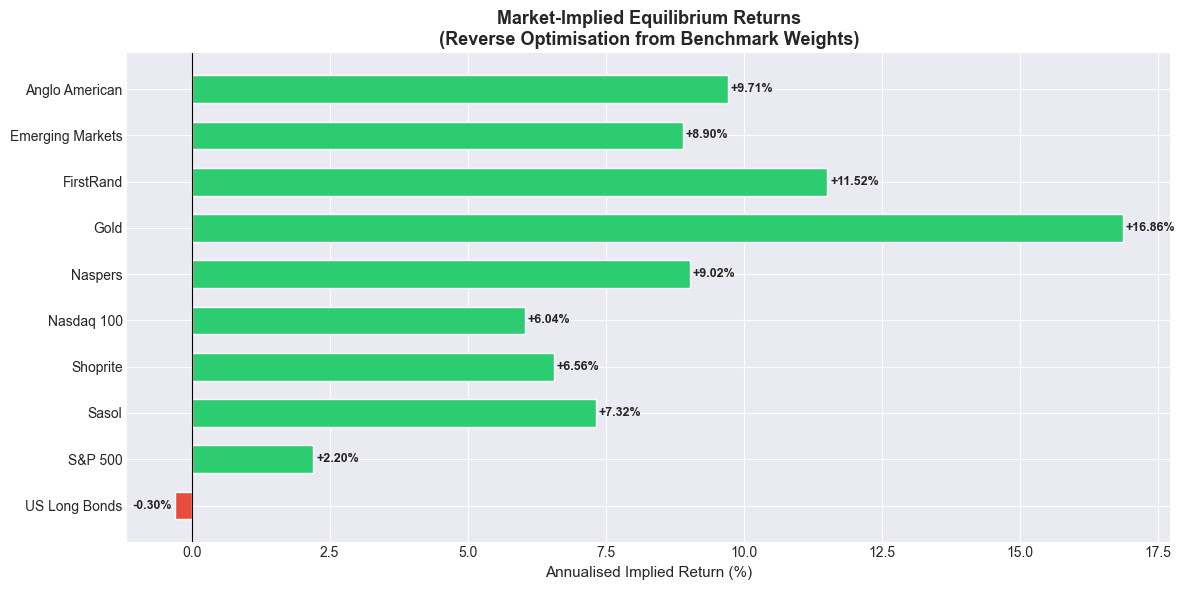

Chart saved ✓
INTERPRETATION OF IMPLIED RETURNS

These are NOT historical returns.
These are NOT our personal forecasts.

These are the returns that the market MUST be expecting
in order for rational investors to hold assets in exactly
the proportions defined by our benchmark weights.

Key observations:

Highest implied returns (market most 'optimistic' about):
  → Gold                : +16.8646%
  → FirstRand           : +11.5155%
  → Anglo American      : +9.7138%

Lowest implied returns (market most 'cautious' about):
  → Nasdaq 100          : +6.0357%
  → S&P 500             : +2.2036%
  → US Long Bonds       : -0.3032%

In Step 3, we will BLEND these market-implied returns
with our own views (e.g. "we think financials will 
outperform by 2%") to produce the final Black-Litterman
combined expected returns.

That blending is the heart of the model.

Files saved:
  → data/implied_returns.csv
  → data/model_parameters.csv

Step 2 Complete ✓
